In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/biohub-cell-tracking-during-development/sample_submission.csv
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/zarr.json
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/7/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/47/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/17/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/81/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/19/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845f.zarr/0/c/22/0/0/0
/kaggle/input/competitions/biohub-cell-tracking-during-development/test/44b6_0b24845

# Biohub – Cell Tracking During Development

## Chapter 6: Tuning and Evaluating the Baseline Detector

**Objective:** Build a simple evaluation workflow for cell detection on a single timepoint, compare detector settings, and measure how often predicted points fall near the ground-truth centroids.

# 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- compare predicted centroids to ground-truth centroids
- compute distances between predictions and labels in 3D
- define a simple matching rule for detection
- estimate true positives, false positives, and missed labels
- compare a looser detector and a stricter detector quantitatively

# 🧠 Background Theory

In Chapter 5, I built a simple local-maxima detector for one 3D microscopy frame.

That detector produced candidate cell centers, but I still need a way to evaluate how good those predictions are.

For this notebook, I will treat detection as a **matching problem**:

- ground-truth centroids = target points
- predicted centroids = detector output
- evaluation = how well the predicted points line up with the target points

This is not the full Kaggle competition metric. It is a simpler notebook-level scoring system that helps me tune a baseline detector before moving to tracking.

# 🗺️ Chapter Roadmap

This notebook will proceed in six stages:

1. **Reload one sample, one timepoint, and the detector outputs**
2. **Represent ground truth and predictions as 3D point sets**
3. **Compute pairwise distances between predictions and labels**
4. **Build a simple matching rule**
5. **Estimate true positives, false positives, and missed labels**
6. **Compare the loose and strict detector settings**

# 📚 New Vocabulary

## True Positive (TP)
A predicted point that correctly matches a ground-truth centroid.

## False Positive (FP)
A predicted point that does not correspond to any ground-truth centroid.

## False Negative (FN)
A ground-truth centroid that was not successfully detected.

## Matching Radius / Distance Threshold
The maximum distance allowed between a predicted point and a ground-truth point for them to count as a match.

In [2]:
!pip install zarr -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.7/363.7 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 80.3 MB/s eta 0:00:00


In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import zarr

from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter

print("Imports successful.")

Imports successful.


# Step 1 — Reload the Sample and the Detection Frame

To keep the experiment consistent, I will continue using the same training sample and the same labeled timepoint from Chapter 5.

In [4]:
competition_path = Path("/kaggle/input/competitions/biohub-cell-tracking-during-development")
train_path = competition_path / "train"

sample_id = "44b6_12dfb391"
zarr_path = train_path / f"{sample_id}.zarr"
geff_path = train_path / f"{sample_id}.geff"

# Load image
volume = zarr.open(zarr_path, mode="r")
image = volume["0"]

# Load graph
geff = zarr.open(geff_path, mode="r")

node_ids = geff["nodes/ids"][:]
t_vals = geff["nodes/props/t/values"][:]
z_vals = geff["nodes/props/z/values"][:]
y_vals = geff["nodes/props/y/values"][:]
x_vals = geff["nodes/props/x/values"][:]

nodes_df = pd.DataFrame({
    "node_id": node_ids,
    "t": t_vals,
    "z": z_vals,
    "y": y_vals,
    "x": x_vals
})

# Use the same timepoint as Chapter 5
t = 8
frame_3d = image[t]
gt_nodes_t = nodes_df[nodes_df["t"] == t].copy().sort_values("z")

print("Frame shape:", frame_3d.shape)
print("Ground-truth nodes at t=8:", len(gt_nodes_t))
gt_nodes_t

Frame shape: (64, 256, 256)
Ground-truth nodes at t=8: 11


,node_id,t,z,y,x
82,114000000041,8,10,237,65
81,114000000040,8,15,184,60
87,114000000080,8,17,248,101
90,114000000084,8,18,2,116
89,114000000082,8,22,199,63
84,114000000043,8,25,208,115
83,114000000042,8,27,156,0
88,114000000081,8,28,122,100
80,114000000037,8,37,50,192
86,114000000063,8,40,198,98


In [5]:
from skimage.feature import peak_local_max
from scipy.ndimage import gaussian_filter

# Smooth the frame once
smoothed_frame = gaussian_filter(frame_3d, sigma=1)

# Loose detector
predicted_points = peak_local_max(
    smoothed_frame,
    min_distance=5,
    threshold_abs=np.percentile(smoothed_frame, 99.5),
    exclude_border=False
)

pred_df = pd.DataFrame(predicted_points, columns=["z", "y", "x"])

# Strict detector
predicted_points_strict = peak_local_max(
    smoothed_frame,
    min_distance=8,
    threshold_abs=np.percentile(smoothed_frame, 99.8),
    exclude_border=False
)

pred_strict_df = pd.DataFrame(predicted_points_strict, columns=["z", "y", "x"])

print("Loose detector predictions:", len(pred_df))
print("Strict detector predictions:", len(pred_strict_df))

Loose detector predictions: 144
Strict detector predictions: 83


# Step 3 — Represent Ground Truth and Predictions as 3D Point Sets

For distance-based evaluation, I will represent each centroid as a 3D point `(z, y, x)`.

In [6]:
gt_points = gt_nodes_t[["z", "y", "x"]].to_numpy()
pred_points = pred_df[["z", "y", "x"]].to_numpy()
pred_points_strict = pred_strict_df[["z", "y", "x"]].to_numpy()

print("Ground-truth points:", gt_points.shape)
print("Loose predicted points:", pred_points.shape)
print("Strict predicted points:", pred_points_strict.shape)

Ground-truth points: (11, 3)
Loose predicted points: (144, 3)
Strict predicted points: (83, 3)


# Step 4 — Compute Pairwise Distances Between Ground Truth and Predictions

To evaluate a detector, I need to know how close each predicted point is to each labeled centroid.

I will compute a **distance matrix** where:

- each **row** is one ground-truth point
- each **column** is one predicted point
- each value is the Euclidean distance between them in `(z, y, x)` voxel space

In [7]:
def pairwise_distances_3d(gt_points, pred_points):
    """
    Compute pairwise Euclidean distances between
    ground-truth points and predicted points.

    Parameters
    ----------
    gt_points : np.ndarray of shape (num_gt, 3)
    pred_points : np.ndarray of shape (num_pred, 3)

    Returns
    -------
    distances : np.ndarray of shape (num_gt, num_pred)
    """
    gt = gt_points[:, None, :]      # (num_gt, 1, 3)
    pred = pred_points[None, :, :]  # (1, num_pred, 3)

    distances = np.sqrt(((gt - pred) ** 2).sum(axis=2))
    return distances

In [8]:
dist_loose = pairwise_distances_3d(gt_points, pred_points)
dist_strict = pairwise_distances_3d(gt_points, pred_points_strict)

print("Loose distance matrix shape:", dist_loose.shape)
print("Strict distance matrix shape:", dist_strict.shape)

print("\nFirst 3 GT points vs first 5 loose predictions:")
print(np.round(dist_loose[:3, :5], 2))

Loose distance matrix shape: (11, 144)
Strict distance matrix shape: (11, 83)

First 3 GT points vs first 5 loose predictions:
[[284.16 228.41  46.9   27.48 208.46]
 [251.39 184.88  73.01  59.16 200.06]
 [269.08 224.58  24.7   38.22 179.49]]


In [9]:
match_radius = 6

# Step 5 — Define a Simple Matching Rule

I will use a simple distance-based rule:

- a **ground-truth point is matched** if at least one prediction falls within a chosen radius
- a **prediction is matched** if it falls within that radius of at least one ground-truth point

This gives me a notebook-level approximation of:

- detected labels
- missed labels
- extra predictions

In [10]:
def evaluate_detector(gt_points, pred_points, match_radius=6):
    """
    Evaluate a detector using a simple distance threshold.

    A GT point is matched if at least one prediction is within match_radius.
    A prediction is matched if at least one GT point is within match_radius.

    Returns a dictionary of counts plus the distance matrix.
    """
    dist = pairwise_distances_3d(gt_points, pred_points)

    # For each GT point: distance to closest prediction
    min_dist_gt = dist.min(axis=1)

    # For each prediction: distance to closest GT point
    min_dist_pred = dist.min(axis=0)

    gt_matched_mask = min_dist_gt <= match_radius
    pred_matched_mask = min_dist_pred <= match_radius

    num_gt = len(gt_points)
    num_pred = len(pred_points)

    tp_gt = gt_matched_mask.sum()          # GT points successfully detected
    fn_gt = num_gt - tp_gt                 # GT points missed
    matched_pred = pred_matched_mask.sum() # predictions close to at least one GT
    fp_pred = num_pred - matched_pred      # predictions not close to any GT

    results = {
        "match_radius": match_radius,
        "num_gt": num_gt,
        "num_pred": num_pred,
        "gt_detected": int(tp_gt),
        "gt_missed": int(fn_gt),
        "pred_matched": int(matched_pred),
        "pred_unmatched": int(fp_pred),
        "gt_recall": tp_gt / num_gt if num_gt > 0 else np.nan,
        "pred_precision_like": matched_pred / num_pred if num_pred > 0 else np.nan,
        "distance_matrix": dist,
        "min_dist_gt": min_dist_gt,
        "min_dist_pred": min_dist_pred,
        "gt_matched_mask": gt_matched_mask,
        "pred_matched_mask": pred_matched_mask,
    }

    return results

In [11]:
loose_results = evaluate_detector(gt_points, pred_points, match_radius=6)
strict_results = evaluate_detector(gt_points, pred_points_strict, match_radius=6)

summary_df = pd.DataFrame([
    {
        "detector": "loose",
        "num_gt": loose_results["num_gt"],
        "num_pred": loose_results["num_pred"],
        "gt_detected": loose_results["gt_detected"],
        "gt_missed": loose_results["gt_missed"],
        "pred_matched": loose_results["pred_matched"],
        "pred_unmatched": loose_results["pred_unmatched"],
        "gt_recall": loose_results["gt_recall"],
        "pred_precision_like": loose_results["pred_precision_like"],
    },
    {
        "detector": "strict",
        "num_gt": strict_results["num_gt"],
        "num_pred": strict_results["num_pred"],
        "gt_detected": strict_results["gt_detected"],
        "gt_missed": strict_results["gt_missed"],
        "pred_matched": strict_results["pred_matched"],
        "pred_unmatched": strict_results["pred_unmatched"],
        "gt_recall": strict_results["gt_recall"],
        "pred_precision_like": strict_results["pred_precision_like"],
    }
])

summary_df

,detector,num_gt,num_pred,gt_detected,gt_missed,pred_matched,pred_unmatched,gt_recall,pred_precision_like
0,loose,11,144,4,7,4,140,0.363636,0.027778
1,strict,11,83,3,8,3,80,0.272727,0.036145


# Step 6 — Inspect Which Ground-Truth Cells Were Missed

The summary table tells me how many labels were detected, but not which ones.

To understand detector failure, I will attach the nearest-prediction distance to each ground-truth centroid and see which labeled cells were matched or missed.

In [12]:
gt_eval_loose = gt_nodes_t.copy()

gt_eval_loose["nearest_pred_dist"] = loose_results["min_dist_gt"]
gt_eval_loose["matched"] = loose_results["gt_matched_mask"]

gt_eval_loose

,node_id,t,z,y,x,nearest_pred_dist,matched
82,114000000041,8,10,237,65,23.790755,False
81,114000000040,8,15,184,60,13.928388,False
87,114000000080,8,17,248,101,17.578396,False
90,114000000084,8,18,2,116,30.854497,False
89,114000000082,8,22,199,63,3.605551,True
84,114000000043,8,25,208,115,17.521415,False
83,114000000042,8,27,156,0,2.000000,True
88,114000000081,8,28,122,100,16.881943,False
80,114000000037,8,37,50,192,9.486833,False
86,114000000063,8,40,198,98,3.741657,True


In [13]:
gt_eval_loose.sort_values("nearest_pred_dist", ascending=False)

,node_id,t,z,y,x,nearest_pred_dist,matched
90,114000000084,8,18,2,116,30.854497,False
82,114000000041,8,10,237,65,23.790755,False
87,114000000080,8,17,248,101,17.578396,False
84,114000000043,8,25,208,115,17.521415,False
88,114000000081,8,28,122,100,16.881943,False
81,114000000040,8,15,184,60,13.928388,False
80,114000000037,8,37,50,192,9.486833,False
85,114000000056,8,42,118,138,5.000000,True
86,114000000063,8,40,198,98,3.741657,True
89,114000000082,8,22,199,63,3.605551,True


In [14]:
gt_eval_strict = gt_nodes_t.copy()

gt_eval_strict["nearest_pred_dist"] = strict_results["min_dist_gt"]
gt_eval_strict["matched"] = strict_results["gt_matched_mask"]

gt_eval_strict.sort_values("nearest_pred_dist", ascending=False)

,node_id,t,z,y,x,nearest_pred_dist,matched
90,114000000084,8,18,2,116,30.854497,False
87,114000000080,8,17,248,101,24.698178,False
82,114000000041,8,10,237,65,23.790755,False
88,114000000081,8,28,122,100,21.748563,False
80,114000000037,8,37,50,192,19.026298,False
83,114000000042,8,27,156,0,18.439089,False
84,114000000043,8,25,208,115,17.521415,False
81,114000000040,8,15,184,60,13.928388,False
85,114000000056,8,42,118,138,5.000000,True
86,114000000063,8,40,198,98,3.741657,True


# Step 7 — Visualize Missed Ground-Truth Cells

The score table shows which labels were missed, but I want to inspect those misses visually.

I will plot the missed ground-truth cells on their z-slices to understand whether they are dim, crowded, or simply not strong local maxima.

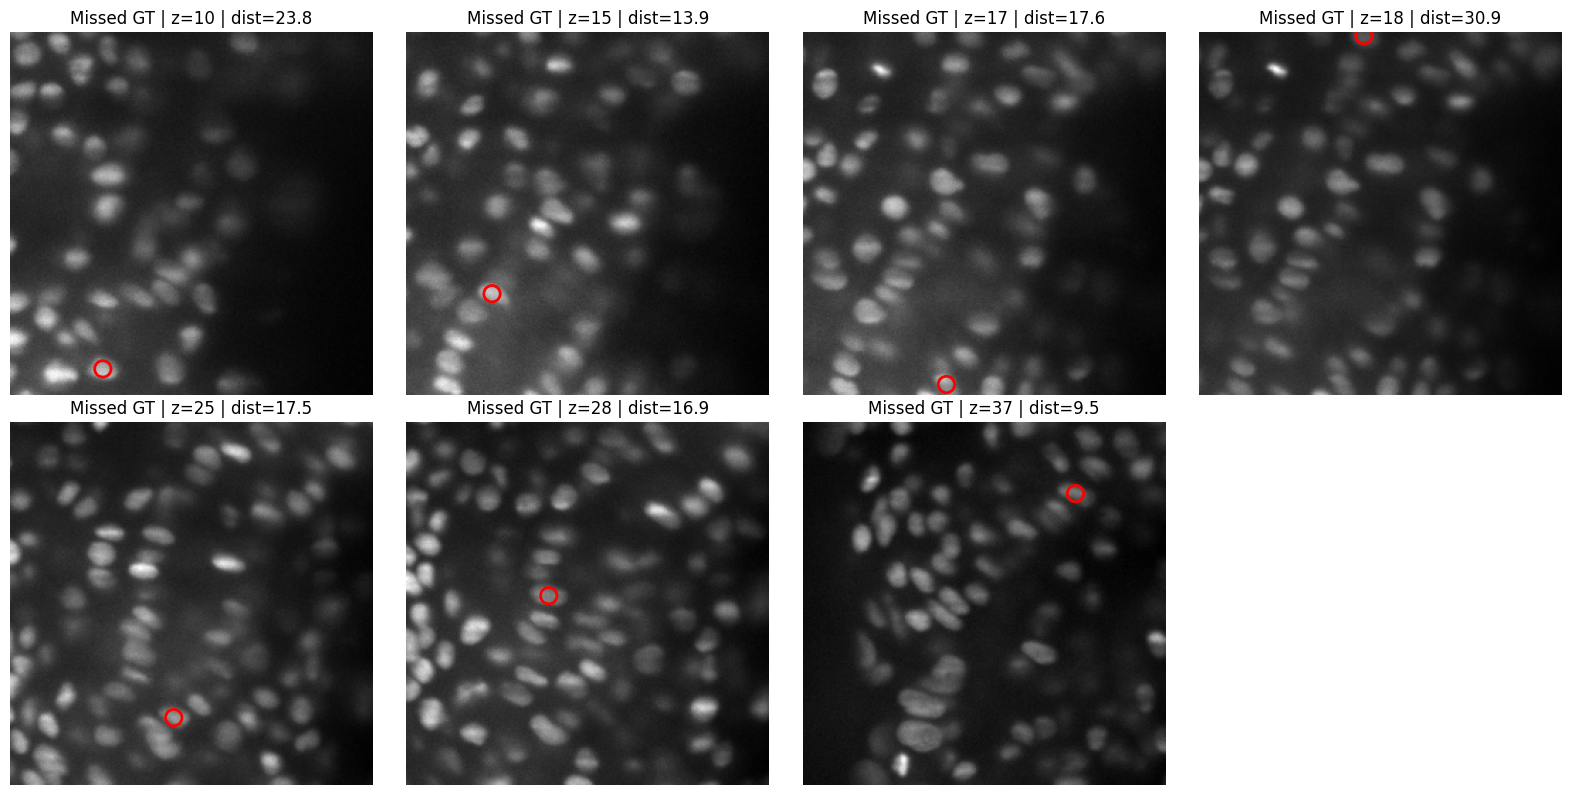

In [15]:
missed_gt = gt_eval_loose[gt_eval_loose["matched"] == False].copy()

z_slices_missed = missed_gt["z"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for ax, (_, row) in zip(axes, missed_gt.iterrows()):
    z = int(row["z"])
    y = int(row["y"])
    x = int(row["x"])

    ax.imshow(frame_3d[z], cmap="gray")
    ax.scatter([x], [y], s=140, facecolors="none", edgecolors="red", linewidths=2)
    ax.set_title(f"Missed GT | z={z} | dist={row['nearest_pred_dist']:.1f}")
    ax.axis("off")

for ax in axes[len(missed_gt):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Step 8 — Compare Ground-Truth Distances for the Loose and Strict Detectors

To compare the two detector settings more directly, I will build a table showing the nearest-prediction distance for each ground-truth centroid under both detectors.

In [16]:
gt_compare = gt_nodes_t[["node_id", "t", "z", "y", "x"]].copy()
gt_compare["loose_nearest_dist"] = loose_results["min_dist_gt"]
gt_compare["loose_matched"] = loose_results["gt_matched_mask"]
gt_compare["strict_nearest_dist"] = strict_results["min_dist_gt"]
gt_compare["strict_matched"] = strict_results["gt_matched_mask"]

gt_compare.sort_values("z")

,node_id,t,z,y,x,loose_nearest_dist,loose_matched,strict_nearest_dist,strict_matched
82,114000000041,8,10,237,65,23.790755,False,23.790755,False
81,114000000040,8,15,184,60,13.928388,False,13.928388,False
87,114000000080,8,17,248,101,17.578396,False,24.698178,False
90,114000000084,8,18,2,116,30.854497,False,30.854497,False
89,114000000082,8,22,199,63,3.605551,True,3.605551,True
84,114000000043,8,25,208,115,17.521415,False,17.521415,False
83,114000000042,8,27,156,0,2.000000,True,18.439089,False
88,114000000081,8,28,122,100,16.881943,False,21.748563,False
80,114000000037,8,37,50,192,9.486833,False,19.026298,False
86,114000000063,8,40,198,98,3.741657,True,3.741657,True


# 📊 Results

In this chapter, I built a simple notebook-level evaluation workflow for the baseline detector on one 3D frame (`sample = 44b6_12dfb391`, `t = 8`).

## Ground truth
- **11 labeled cell centroids**

## Detector outputs
### Loose detector
- `min_distance = 5`
- threshold = 99.5th percentile
- **144 predicted points**

### Strict detector
- `min_distance = 8`
- threshold = 99.8th percentile
- **83 predicted points**

## Simple distance-based evaluation (`match_radius = 6` voxels)

### Loose detector
- **GT detected:** 4 / 11
- **GT missed:** 7 / 11
- **Matched predictions:** 4 / 144
- **Unmatched predictions:** 140 / 144
- **GT recall:** 0.364
- **Precision-like score:** 0.028

### Strict detector
- **GT detected:** 3 / 11
- **GT missed:** 8 / 11
- **Matched predictions:** 3 / 83
- **Unmatched predictions:** 80 / 83
- **GT recall:** 0.273
- **Precision-like score:** 0.036

# 🔍 Analysis

This notebook showed that a simple 3D local-maxima detector is not sufficient to recover most of the sparse ground-truth labels, even on a single timepoint.

## Main findings

### 1. The detector finds many bright peaks, but most do not match labeled centroids
Both detector settings produced far more predicted points than labeled cells.

### 2. Tightening the detector reduced false positives, but also reduced recall
The strict detector produced fewer peaks, but it detected fewer labeled cells.

### 3. Missed labels are often in crowded or ambiguous regions
Visual inspection suggests that some missed ground-truth cells are not the strongest local maxima in their local neighborhoods.

### 4. Sparse labels complicate interpretation
Some unmatched predictions may correspond to real cells that are simply unlabeled in the sparse ground-truth graph.

## Takeaway
A useful detector for this competition will need more than a simple local-maxima rule. It may need:

- better preprocessing
- a more biologically informed blob detector
- 3D candidate filtering
- or eventually a learned model

# 📝 What I Learned

Today I learned that:

- detector evaluation can be framed as a 3D point-matching problem
- distance matrices are a simple way to compare predictions to labels
- a matching radius lets me estimate notebook-level TP / FP / FN behavior
- a detector can reduce false positives and still become worse if recall drops
- visualizing the missed ground-truth cells is essential for understanding failure modes

# 🚀 Next Steps

## Chapter 7 — Improve the Baseline Detector

In the next notebook, I want to try a better non-deep-learning detector.

Possible directions:

- use **Difference of Gaussians** or **Laplacian of Gaussian** blob detection
- evaluate detections in **physical units** using the voxel spacing
- add simple non-maximum suppression or candidate filtering
- compare multiple detector families on the same timepoint
- see whether a better detector improves recall before moving on to tracking